# Using Frequentist approach to estimate parameters of Non-Stationary Generalized Pareto Distribution (GPD)

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown
from scipy.stats import chi2, genpareto

import nsEVDx as ns

#### Loading Partial Duration Series (PDS) and Covariates

- The Partial Duration Series (PDS) is derived from the same rainfall station in Georgia used for the Annual Maxima Series (AMS) and contains 60-minute rainfall maxima.
- Unlike AMS, PDS may include multiple extreme events per year or skip years with no significant peaks.
- This dataset has an average threshold rate of 2 events per year, resulting in a PDS of 100 maxima.
- The same covariates used in the GEV example, temperature anomaly and NAO index, are applied here.
- Covariates are assigned to each PDS event by matching the corresponding year.
- This setup enables modeling of short-duration extremes influenced by interannual climate variability.


In [2]:
dist = genpareto
# Annual maxima series
PDS_df = pd.read_csv("data/Partial_duration_series.csv", index_col=0)
print(PDS_df.head(3))

# Covariates
cov_df = pd.read_csv("data/temp_anomaly_&_NAO.csv", index_col=0)
print(cov_df.head(3))

   year  60_min_maxima
0  1976          48.26
1  1977          53.34
2  1977          38.10
   year  temp_anomaly   NAO
0  1975          0.00 -2.21
1  1976          0.00 -1.53
2  1977          0.01 -1.35


In [3]:
# Add temperature anomaly and NAO index to each PDS record by matching year
PDS_df["temp_anomaly"] = PDS_df["year"].apply(
    lambda y: cov_df.loc[cov_df["year"] == y, "temp_anomaly"].values[0]
)
PDS_df["NAO"] = PDS_df["year"].apply(
    lambda y: cov_df.loc[cov_df["year"] == y, "NAO"].values[0]
)

print(PDS_df.head())

   year  60_min_maxima  temp_anomaly   NAO
0  1976          48.26          0.00 -1.53
1  1977          53.34          0.01 -1.35
2  1977          38.10          0.01 -1.35
3  1979          43.18          0.03  2.99
4  1979          30.48          0.03  2.99


#### Visualizing the input data

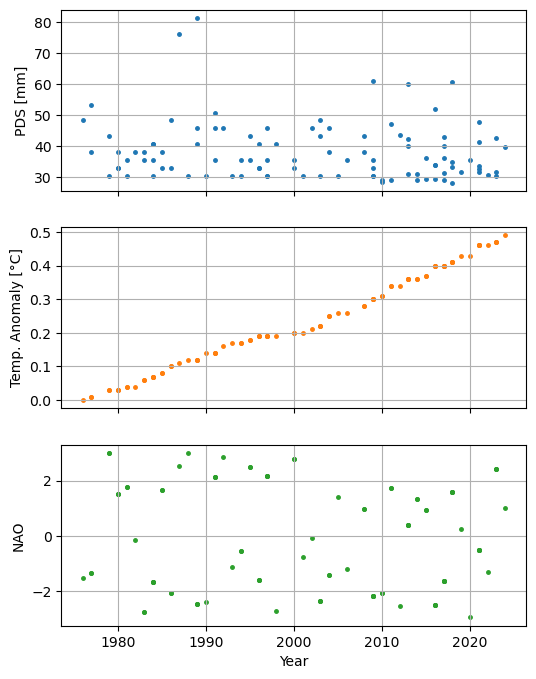

In [4]:
# Extract data from PDS_df
years = PDS_df["year"]
rainfall = PDS_df["60_min_maxima"]
temp_anomaly = PDS_df["temp_anomaly"]
NAO = PDS_df["NAO"]

# Set up subplots
fig, axs = plt.subplots(3, 1, figsize=(6, 8), sharex=True)
data_list = [rainfall, temp_anomaly, NAO]
labels = ["PDS [mm]", "Temp. Anomaly [°C]", "NAO"]
colors = ["tab:blue", "tab:orange", "tab:green"]

# Plot each series
for ax, series, label, color in zip(axs, data_list, labels, colors):
    ax.scatter(years, series, label=label, color=color, marker=".", s=25)
    ax.set_ylabel(label)
    ax.grid(True)

axs[-1].set_xlabel("Year")
plt.show()

#### Preparing Covariates and PDS data for Non-Stationary GEV Sampler

To model a non-stationary GPD, we must prepare the **covariate matrix** and **time vector** in a format compatible with the sampler. This typically means:

1. **Converting covariates into a NumPy array**, ensuring they are aligned with the response variable (e.g., PDS).
2. **Centering the time variable** (e.g., years) by subtracting the mid-point of the record period. This helps reduce multicollinearity and improve MCMC convergence.

- Our record spans from 1975 to 2024. So, the mid-year is:
- mid_year = int((1975 + 2024) / 2)  =  1999
  ```python
  cov_df['year'] = cov_df['year'] - 1999
  ```

In [5]:
data = PDS_df["60_min_maxima"].values  # data should be in chronological order
PDS_df["year"] = PDS_df["year"] - 1999
PDS_df.head(3)

# Here, if you mess up the time covariate by running this block multiple times,
# please load PDS and Covariates again

,year,60_min_maxima,temp_anomaly,NAO
0,-23,48.26,0.00,-1.53
1,-22,53.34,0.01,-1.35
2,-22,38.10,0.01,-1.35


In [6]:
# Transposing the covariate as per the need of sampler
cov = PDS_df[["year", "temp_anomaly", "NAO"]].values.T
cov.shape

(3, 100)

#### Estimating the stationary GPD parameters 
In the following block, we estimate the stationary GPD parameters. This serves two key purposes:
- To obtain a realistic initial guess for the non-stationary model parameters.
- To define appropriate bound for the optimizer.

In [7]:
shape, loc, scale = ns.EVD_parsViaMLE(data, dist)
print(f"Shape : {shape}, Loc : {loc}, Scale : {scale}")

Shape : -0.057632322705710615, Loc : 28.193999999601207, Scale : 10.596502738669685


#### Setting up the Non-Stationary GPD Sampler
We now configure the non-stationary GPD model by specifying which parameters are modeled as functions of covariates. This is done using a config list:
```python
config = [1, 0, 0]
```
means:
- Location (μ) is a linear function of one covariates (intercept + 1 covariates, i.e., time)
- Scale (σ) is is constant (no covariate dependency)
- Shape (ξ) is constant (no covariate dependency)


In [8]:
config = [1, 0, 0]
# lets verify the description of the parameters we are going to estimate
ns.NonStationaryEVD.get_param_description(config, cov.shape[0])

['B0 (location intercept)',
 'B1 (location slope for covariate 1)',
 'sigma (scale)',
 'xi (shape)']

In [9]:
# Preparing initial guess for the parameters
initial_params = [loc, 0, scale, shape]
print(initial_params)

[np.float64(28.193999999601207), 0, np.float64(10.596502738669685), np.float64(-0.057632322705710615)]


#### Specifying the bounds and running frequentist sampler
It is best practice to instantiate the sampler with bounds explictly, or assign user defined bounds, rather than relying on default or automatically inferred bounds by the sampler.

In [10]:
sampler = ns.NonStationaryEVD(config, data, cov, dist=dist)
sampler.suggest_bounds()

[(np.float64(14.341977975397425), np.float64(43.02593392619227)),
 (-0.1, 0.1),
 (np.float64(4.900027940507415), np.float64(19.60011176202966)),
 (np.float64(-0.22800908402725203), np.float64(0.171990915972748))]

In [11]:
# Modifying the suggested bounds
sampler.bounds = [
    (None, None),
    (None, None),
    (np.float64(1), np.float64(14)),
    (np.float64(-0.25), np.float64(0.25)),
]

In [12]:
estimates = sampler.frequentist_nsEVD(initial_params, max_retries=10)

In [13]:
np.set_printoptions(suppress=True, precision=6)
print(estimates)
sampler.descriptions

[28.528778  0.942297 10.596507 -0.057603]


['B0 (location intercept)',
 'B1 (location slope for covariate 1)',
 'sigma (scale)',
 'xi (shape)']

In [14]:
md_text = f"""
### Interpretation of the Estimated GPD Parameters

The frequentist optimizer returned the following parameter values for the
non-stationary GPD model:

- **Location (μ)**:
  - `B0 = {estimates[0]:.3f}`: Intercept (baseline level)
  - `B1 = {estimates[1]:.6f}`: Effect of covariate 1 on location parameter.
  This value suggest that, the magnitude of location parameter and in turn
  the magnitude of extremes reduces with time

- **Scale (σ)**:
  - `σ = {estimates[2]:.3f}`: Estimated scale parameter

- **Shape (ξ)**:
  - `ξ = {estimates[3]:.6f}`: Controls tail heaviness; negative ξ suggests an upper
    bound of `(-1/ξ)` on extremes.
"""
Markdown(md_text)


### Interpretation of the Estimated GPD Parameters

The frequentist optimizer returned the following parameter values for the
non-stationary GPD model:

- **Location (μ)**:
  - `B0 = 28.529`: Intercept (baseline level)
  - `B1 = 0.942297`: Effect of covariate 1 on location parameter.
  This value suggest that, the magnitude of location parameter and in turn
  the magnitude of extremes reduces with time

- **Scale (σ)**:
  - `σ = 10.597`: Estimated scale parameter

- **Shape (ξ)**:
  - `ξ = -0.057603`: Controls tail heaviness; negative ξ suggests an upper
    bound of `(-1/ξ)` on extremes.


#### Likelihood ratio test for frequentist approach

In [15]:
# Likelihood ratio test for frequentist approach
st_params = ns.EVD_parsViaMLE(data, dist)[[1, 2, 0]]  # estimating stationary parameters
ns_params = estimates  # assigning non-stationary parameters to different variable
ll_st = -ns.neg_log_likelihood(
    st_params, data, dist
)  # log likelihood of the stationary parameters
ll_ns = -ns.neg_log_likelihood_ns(
    ns_params, data, cov, config, dist
)  # Log likelihood of non-stationary parameters

In [16]:
st_config = [0, 0, 0]  # base parameter config for the stationary model
test_stat = 2 * (ll_ns - ll_st)  # deviance statistics or likelihood ratio
df = sum(config) - sum(st_config)  # computing degree of freedom
p_val = chi2.sf(
    test_stat, df
)  # Since deviance stat follow chi2 dist, computing p-value using chi2

print(f"Likelihood Ratio (LR) Statistic = {test_stat:.3f}")
print(f"Degrees of Freedom = {df}")
print(f"p-value = {p_val:.4f}")

alpha = 0.05  # or 0.01, depending on your test
critical_value = chi2.ppf(1 - alpha, df)
print(f"Critical value at α = {alpha} is {critical_value:.3f}")

# if LR > critical value , it is highly likely the non-stationary model fits the given
# data better

Likelihood Ratio (LR) Statistic = 46.272
Degrees of Freedom = 1
p-value = 0.0000
Critical value at α = 0.05 is 3.841


In [17]:
# AIC test for frequentist approach: lower AIC indicates a better model.
# Interpretation of delta_AIC (difference in AIC between models):
#   0–2  - Models are essentially equivalent.
#   2–7  - Weak evidence favoring the model with lower AIC.
#   >10  - Strong evidence favoring the model with lower AIC.
k_st = 3  # location, scale, shape
k_ns = sum(config) + 3
aic_st = 2 * k_st - 2 * ll_st
aic_ns = 2 * k_ns - 2 * ll_ns
print(f"AIC (stationary) = {aic_st:.2f}, AIC (nonstationary) = {aic_ns:.2f}")
delta_aic = abs(aic_ns - aic_st)
print(f"delta_AIC : {delta_aic}")

# The model with lower AIC should be preffered over the model with higher AIC

AIC (stationary) = 666.58, AIC (nonstationary) = 622.31
delta_AIC : 44.27231076704197
